# JRN Cross-Task Transfer Analysis on rel-f1 and rel-stack

**Join Reproduction Number (JRN)** measures how much each database join improves a predictive task.
This notebook analyzes pre-computed JRN matrices across multiple tasks on two relational benchmarks
(rel-f1 and rel-stack), computing:

- **Leave-one-task-out transfer rho** — how well universal JRN rankings predict held-out task rankings
- **Pairwise Spearman rho** — correlation between task-specific JRN rankings
- **Kendall's W concordance** — overall agreement across all tasks
- **Entity-table & task-type concordance** — same-entity vs cross-entity transferability
- **Universal vs task-specific gaps** — practical impact of using a shared JRN ranking
- **Cost-adjusted recommendations** — when per-task JRN is worth the extra computation

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
# scipy==1.16.3 requires Python >=3.11; fall back to 1.15.3 on Python 3.10
if 'google.colab' not in sys.modules:
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import json
import math
import os
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.stats import kendalltau, rankdata, spearmanr
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## Load Pre-computed JRN Data

Load pre-computed JRN results from GitHub (with local fallback). The data contains JRN measurements for all (task, join) pairs on rel-f1 and rel-stack benchmarks.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-bc07ab-join-reproduction-number-epidemiology-in/main/experiment_iter6_jrn_cross_task/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {sum(len(d['examples']) for d in data['datasets'])} examples across {len(data['datasets'])} datasets")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 93 examples across 2 datasets
  rel-f1: 55 examples
  rel-stack: 38 examples


## Configuration

Tunable parameters for the analysis. These match the original experiment settings.

In [5]:
# --- Config ---
# Number of random seeds for practical impact random baseline
NUM_RANDOM_SEEDS = 10  # original: 10
# Top-k values for universal vs task-specific comparison
TOP_K_VALUES = [1, 2, 3]  # original: [1, 2, 3]
# Gap threshold (%) for recommending universal vs per-task JRN
GAP_THRESHOLD_PCT = 5.0  # original: 5.0

## Reconstruct JRN Matrix from Pre-computed Data

Parse the loaded examples to reconstruct the JRN matrix (task × join) and task metadata for each dataset.

In [6]:
def reconstruct_jrn_data(data):
    """Reconstruct JRN matrices and task info from loaded examples."""
    all_dataset_results = {}

    for ds_entry in data["datasets"]:
        dataset_name = ds_entry["dataset"]
        examples = ds_entry["examples"]

        # Extract JRN measurements
        jrn_matrix = {}  # task -> join_id -> {jrn_mean, jrn_std, jrn_seeds, hop_distance}
        tasks_info = {}  # task -> {entity_table, task_type}

        for ex in examples:
            if ex.get("metadata_type") != "jrn_measurement":
                continue

            task = ex["metadata_task"]
            join_id = ex["metadata_join"]
            output = json.loads(ex["output"])

            if task not in jrn_matrix:
                jrn_matrix[task] = {}

            jrn_matrix[task][join_id] = {
                "jrn_mean": output["jrn_mean"],
                "jrn_std": output["jrn_std"],
                "jrn_seeds": output["jrn_seeds"],
                "hop_distance": ex.get("metadata_hop_distance", 1),
            }

            if task not in tasks_info:
                inp = json.loads(ex["input"])
                tasks_info[task] = {
                    "entity_table": inp.get("entity_table", "unknown"),
                    "task_type": inp.get("task_type", "classification"),
                }

        all_dataset_results[dataset_name] = {
            "jrn_matrix": jrn_matrix,
            "tasks_info": tasks_info,
        }

        print(f"\n{dataset_name}:")
        print(f"  Tasks: {list(jrn_matrix.keys())}")
        for tname, joins in jrn_matrix.items():
            print(f"  {tname}: {len(joins)} joins, entity={tasks_info[tname]['entity_table']}, type={tasks_info[tname]['task_type']}")

    return all_dataset_results

all_dataset_results = reconstruct_jrn_data(data)


rel-f1:
  Tasks: ['driver-dnf', 'driver-top3', 'driver-position', 'results-position', 'qualifying-position']
  driver-dnf: 8 joins, entity=drivers, type=classification
  driver-top3: 8 joins, entity=drivers, type=classification
  driver-position: 8 joins, entity=drivers, type=regression
  results-position: 13 joins, entity=results, type=regression
  qualifying-position: 13 joins, entity=qualifying, type=regression

rel-stack:
  Tasks: ['user-engagement', 'user-badge', 'post-votes']
  user-engagement: 11 joins, entity=users, type=classification
  user-badge: 11 joins, entity=users, type=classification
  post-votes: 11 joins, entity=posts, type=regression


## Leave-One-Task-Out Transfer Analysis

For each task, compute Spearman rho between its JRN ranking and the "universal" ranking from remaining tasks. High rho means the universal ranking transfers well.

In [7]:
def compute_transfer_analysis(jrn_matrix):
    """Compute leave-one-task-out transfer Spearman rho."""
    task_name_list = list(jrn_matrix.keys())
    all_join_sets = [set(jrn_matrix[t].keys()) for t in task_name_list]
    all_joins_union = sorted(set.union(*all_join_sets)) if all_join_sets else []

    transfer_rhos = {}
    for held_out_task in task_name_list:
        remaining_tasks = [t for t in task_name_list if t != held_out_task]

        if len(remaining_tasks) < 1 or len(all_joins_union) < 3:
            transfer_rhos[held_out_task] = {"rho": None, "pval": None}
            continue

        held_out_jrn = [
            jrn_matrix[held_out_task].get(j, {}).get("jrn_mean", 1.0)
            for j in all_joins_union
        ]

        universal_jrn = []
        for j in all_joins_union:
            vals = [jrn_matrix[t].get(j, {}).get("jrn_mean", 1.0) for t in remaining_tasks]
            universal_jrn.append(np.mean(vals))

        rho, pval = spearmanr(held_out_jrn, universal_jrn)
        if np.isnan(rho):
            transfer_rhos[held_out_task] = {"rho": None, "pval": None}
        else:
            transfer_rhos[held_out_task] = {"rho": float(rho), "pval": float(pval)}

    valid_rhos = [v["rho"] for v in transfer_rhos.values() if v["rho"] is not None]
    mean_transfer_rho = float(np.mean(valid_rhos)) if valid_rhos else None

    return {
        "per_task_transfer_rho": transfer_rhos,
        "mean_transfer_rho": mean_transfer_rho,
        "num_all_joins": len(all_joins_union),
    }

for ds_name, ds_data in all_dataset_results.items():
    transfer = compute_transfer_analysis(ds_data["jrn_matrix"])
    ds_data["transfer_analysis"] = transfer
    print(f"\n{ds_name} — Transfer Analysis:")
    print(f"  Mean transfer rho: {transfer['mean_transfer_rho']:.4f}")
    for task, rho_info in transfer["per_task_transfer_rho"].items():
        rho_str = f"{rho_info['rho']:.4f}" if rho_info['rho'] is not None else "N/A"
        print(f"  {task}: rho={rho_str}")


rel-f1 — Transfer Analysis:
  Mean transfer rho: 0.3734
  driver-dnf: rho=0.5369
  driver-top3: rho=0.4182
  driver-position: rho=0.3787
  results-position: rho=0.2912
  qualifying-position: rho=0.2418

rel-stack — Transfer Analysis:
  Mean transfer rho: 0.2061
  user-engagement: rho=0.7545
  user-badge: rho=0.6545
  post-votes: rho=-0.7909


## Pairwise Spearman Rho & Kendall's W Concordance

Compute pairwise correlations between tasks' JRN rankings and Kendall's W (overall concordance across all raters/tasks).

In [8]:
def compute_concordance(jrn_matrix):
    """Compute pairwise Spearman rho and Kendall's W."""
    task_name_list = list(jrn_matrix.keys())
    all_join_sets = [set(jrn_matrix[t].keys()) for t in task_name_list]
    all_joins_union = sorted(set.union(*all_join_sets)) if all_join_sets else []

    k_tasks = len(task_name_list)
    n_joins = len(all_joins_union)

    # Build JRN value matrix
    jrn_rank_matrix = np.zeros((k_tasks, n_joins))
    for i, t in enumerate(task_name_list):
        for k, j in enumerate(all_joins_union):
            jrn_rank_matrix[i, k] = jrn_matrix[t].get(j, {}).get("jrn_mean", 1.0)

    # Pairwise Spearman rho
    pairwise_rho = {}
    for i, t1 in enumerate(task_name_list):
        for j_idx, t2 in enumerate(task_name_list):
            if i < j_idx:
                rho, pval = spearmanr(jrn_rank_matrix[i], jrn_rank_matrix[j_idx])
                if np.isnan(rho):
                    rho, pval = 0.0, 1.0
                pairwise_rho[f"{t1}_vs_{t2}"] = {"rho": float(rho), "pval": float(pval)}

    # Kendall's W
    ranks = np.zeros_like(jrn_rank_matrix)
    for i in range(k_tasks):
        ranks[i] = rankdata(jrn_rank_matrix[i])

    rank_sums = ranks.sum(axis=0)
    mean_rank_sum = rank_sums.mean()
    S = np.sum((rank_sums - mean_rank_sum) ** 2)
    W = 12.0 * S / (k_tasks**2 * (n_joins**3 - n_joins)) if (n_joins > 1 and k_tasks > 0) else 0.0

    return {
        "kendalls_W": float(W),
        "pairwise_spearman_rho": pairwise_rho,
        "num_tasks": k_tasks,
        "num_joins": n_joins,
        "task_name_list": task_name_list,
        "all_joins_union": all_joins_union,
    }

for ds_name, ds_data in all_dataset_results.items():
    concordance = compute_concordance(ds_data["jrn_matrix"])
    ds_data["concordance_analysis"] = concordance
    print(f"\n{ds_name} — Concordance:")
    print(f"  Kendall's W: {concordance['kendalls_W']:.4f} ({concordance['num_tasks']} tasks, {concordance['num_joins']} joins)")
    print(f"  Pairwise Spearman rho:")
    for pair, vals in concordance["pairwise_spearman_rho"].items():
        print(f"    {pair}: rho={vals['rho']:.4f}, p={vals['pval']:.4f}")


rel-f1 — Concordance:
  Kendall's W: 0.5244 (5 tasks, 13 joins)
  Pairwise Spearman rho:
    driver-dnf_vs_driver-top3: rho=0.8488, p=0.0002
    driver-dnf_vs_driver-position: rho=0.9302, p=0.0000
    driver-dnf_vs_results-position: rho=0.2261, p=0.4577
    driver-dnf_vs_qualifying-position: rho=0.4295, p=0.1430
    driver-top3_vs_driver-position: rho=0.8372, p=0.0004
    driver-top3_vs_results-position: rho=0.1526, p=0.6187
    driver-top3_vs_qualifying-position: rho=0.4126, p=0.1612
    driver-position_vs_results-position: rho=0.0509, p=0.8689
    driver-position_vs_qualifying-position: rho=0.2148, p=0.4810
    results-position_vs_qualifying-position: rho=0.2198, p=0.4706

rel-stack — Concordance:
  Kendall's W: 0.2061 (3 tasks, 11 joins)
  Pairwise Spearman rho:
    user-engagement_vs_user-badge: rho=0.8182, p=0.0021
    user-engagement_vs_post-votes: rho=-0.7091, p=0.0146
    user-badge_vs_post-votes: rho=-0.6818, p=0.0208


## Entity-Table & Task-Type Concordance Analysis

Compare same-entity vs cross-entity task pairs, and same-type vs cross-type task pairs to understand what drives JRN transferability.

In [9]:
def compute_task_type_analysis(jrn_matrix, tasks_info, pairwise_rho):
    """Analyze concordance by entity table and task type."""
    task_name_list = list(jrn_matrix.keys())

    entity_groups = defaultdict(list)
    for tname in task_name_list:
        et = tasks_info[tname]["entity_table"]
        entity_groups[et].append(tname)

    same_entity_rhos = []
    cross_entity_rhos = []
    same_type_rhos = []
    cross_type_rhos = []

    for pair_key, pair_val in pairwise_rho.items():
        t1, t2 = pair_key.split("_vs_")
        e1 = tasks_info[t1]["entity_table"]
        e2 = tasks_info[t2]["entity_table"]
        type1 = tasks_info[t1]["task_type"]
        type2 = tasks_info[t2]["task_type"]
        rho_val = pair_val["rho"]

        if rho_val is not None and not np.isnan(rho_val):
            if e1 == e2:
                same_entity_rhos.append(rho_val)
            else:
                cross_entity_rhos.append(rho_val)
            if type1 == type2:
                same_type_rhos.append(rho_val)
            else:
                cross_type_rhos.append(rho_val)

    return {
        "entity_groups": dict(entity_groups),
        "same_entity_mean_rho": float(np.mean(same_entity_rhos)) if same_entity_rhos else None,
        "cross_entity_mean_rho": float(np.mean(cross_entity_rhos)) if cross_entity_rhos else None,
        "same_entity_rhos": same_entity_rhos,
        "cross_entity_rhos": cross_entity_rhos,
        "same_type_mean_rho": float(np.mean(same_type_rhos)) if same_type_rhos else None,
        "cross_type_mean_rho": float(np.mean(cross_type_rhos)) if cross_type_rhos else None,
        "same_type_rhos": same_type_rhos,
        "cross_type_rhos": cross_type_rhos,
    }

for ds_name, ds_data in all_dataset_results.items():
    pairwise_rho = ds_data["concordance_analysis"]["pairwise_spearman_rho"]
    task_type = compute_task_type_analysis(ds_data["jrn_matrix"], ds_data["tasks_info"], pairwise_rho)
    ds_data["task_type_analysis"] = task_type
    print(f"\n{ds_name} — Task-Type Analysis:")
    print(f"  Entity groups: {task_type['entity_groups']}")
    print(f"  Same-entity mean rho:  {task_type['same_entity_mean_rho']}")
    print(f"  Cross-entity mean rho: {task_type['cross_entity_mean_rho']}")
    print(f"  Same-type mean rho:    {task_type['same_type_mean_rho']}")
    print(f"  Cross-type mean rho:   {task_type['cross_type_mean_rho']}")


rel-f1 — Task-Type Analysis:
  Entity groups: {'drivers': ['driver-dnf', 'driver-top3', 'driver-position'], 'results': ['results-position'], 'qualifying': ['qualifying-position']}
  Same-entity mean rho:  0.8720930232558138
  Cross-entity mean rho: 0.24374987608553436
  Same-type mean rho:    0.33356504063800374
  Cross-type mean rho:   0.4980446733023612

rel-stack — Task-Type Analysis:
  Entity groups: {'users': ['user-engagement', 'user-badge'], 'posts': ['post-votes']}
  Same-entity mean rho:  0.8181818181818182
  Cross-entity mean rho: -0.6954545454545455
  Same-type mean rho:    0.8181818181818182
  Cross-type mean rho:   -0.6954545454545455


## Practical Impact: Universal vs Task-Specific Join Selection

For each held-out task, compare top-k joins selected by universal ranking vs oracle task-specific ranking. The gap shows how much performance is lost by using a shared ranking.

In [10]:
def compute_practical_impact(jrn_matrix):
    """Compute universal vs task-specific join selection gaps."""
    task_name_list = list(jrn_matrix.keys())
    practical_per_task = {}

    for held_out_task in task_name_list:
        remaining_tasks = [t for t in task_name_list if t != held_out_task]
        reachable_for_task = list(jrn_matrix[held_out_task].keys())

        if len(reachable_for_task) < 2:
            practical_per_task[held_out_task] = {"note": "too_few_joins"}
            continue

        # Task-specific ranking (oracle)
        task_specific_ranking = sorted(
            reachable_for_task,
            key=lambda j: jrn_matrix[held_out_task][j]["jrn_mean"],
            reverse=True,
        )

        # Universal ranking (mean JRN across remaining tasks)
        universal_jrn_vals = {}
        for j in reachable_for_task:
            vals = [jrn_matrix[t].get(j, {}).get("jrn_mean", 1.0) for t in remaining_tasks]
            universal_jrn_vals[j] = np.mean(vals)
        universal_ranking = sorted(
            reachable_for_task, key=lambda j: universal_jrn_vals[j], reverse=True,
        )

        practical_per_task[held_out_task] = {
            "num_reachable_joins": len(reachable_for_task),
            "top_k_comparisons": {},
        }

        for k_val in TOP_K_VALUES:
            if k_val > len(reachable_for_task):
                break

            ts_top_k = task_specific_ranking[:k_val]
            ts_jrn_mean = np.mean([jrn_matrix[held_out_task][j]["jrn_mean"] for j in ts_top_k])

            uni_top_k = universal_ranking[:k_val]
            uni_jrn_mean = np.mean([jrn_matrix[held_out_task][j]["jrn_mean"] for j in uni_top_k])

            # Random baseline
            random_jrns = []
            for r_seed in range(NUM_RANDOM_SEEDS):
                rng = np.random.RandomState(r_seed)
                selected_random = list(rng.choice(reachable_for_task, k_val, replace=False))
                rand_jrn = np.mean([jrn_matrix[held_out_task][j]["jrn_mean"] for j in selected_random])
                random_jrns.append(rand_jrn)
            random_jrn_mean = np.mean(random_jrns)

            gap = abs(uni_jrn_mean - ts_jrn_mean) / max(abs(ts_jrn_mean), 1e-6)

            practical_per_task[held_out_task]["top_k_comparisons"][f"top_{k_val}"] = {
                "task_specific_mean_jrn": float(ts_jrn_mean),
                "universal_mean_jrn": float(uni_jrn_mean),
                "random_mean_jrn": float(random_jrn_mean),
                "relative_gap_pct": float(gap * 100),
            }

    # Overall mean gap
    all_gaps = []
    for tname, tdata in practical_per_task.items():
        if "top_k_comparisons" in tdata:
            for kk, kdata in tdata["top_k_comparisons"].items():
                all_gaps.append(kdata["relative_gap_pct"])
    mean_gap = float(np.mean(all_gaps)) if all_gaps else 0.0

    return {"per_task": practical_per_task, "mean_gap_pct": mean_gap}

for ds_name, ds_data in all_dataset_results.items():
    practical = compute_practical_impact(ds_data["jrn_matrix"])
    ds_data["practical_impact"] = practical
    print(f"\n{ds_name} — Practical Impact:")
    print(f"  Mean gap: {practical['mean_gap_pct']:.2f}%")
    for task, tdata in practical["per_task"].items():
        if "top_k_comparisons" in tdata:
            for k, kdata in tdata["top_k_comparisons"].items():
                print(f"  {task} {k}: specific={kdata['task_specific_mean_jrn']:.4f}, "
                      f"universal={kdata['universal_mean_jrn']:.4f}, "
                      f"random={kdata['random_mean_jrn']:.4f}, gap={kdata['relative_gap_pct']:.1f}%")


rel-f1 — Practical Impact:
  Mean gap: 14.43%
  driver-dnf top_1: specific=1.1786, universal=1.1137, random=1.1139, gap=5.5%
  driver-dnf top_2: specific=1.1732, universal=1.1408, random=1.1269, gap=2.8%
  driver-dnf top_3: specific=1.1674, universal=1.1325, random=1.1296, gap=3.0%
  driver-top3 top_1: specific=1.1774, universal=1.1716, random=1.1351, gap=0.5%
  driver-top3 top_2: specific=1.1764, universal=1.1735, random=1.1447, gap=0.2%
  driver-top3 top_3: specific=1.1748, universal=1.1618, random=1.1437, gap=1.1%
  driver-position top_1: specific=1.1648, universal=1.0250, random=1.0730, gap=12.0%
  driver-position top_2: specific=1.1470, universal=1.0771, random=1.0893, gap=6.1%
  driver-position top_3: specific=1.1310, universal=1.0692, random=1.0893, gap=5.5%
  results-position top_1: specific=1.6256, universal=1.2335, random=1.1905, gap=24.1%
  results-position top_2: specific=1.4518, universal=1.2558, random=1.1518, gap=13.5%
  results-position top_3: specific=1.3904, universa

## Cost-Adjusted Recommendations

Compare the computational cost of universal vs per-task JRN estimation and recommend the best strategy based on the performance gap.

In [11]:
for ds_name, ds_data in all_dataset_results.items():
    jrn_matrix = ds_data["jrn_matrix"]
    task_name_list = list(jrn_matrix.keys())
    all_join_sets = [set(jrn_matrix[t].keys()) for t in task_name_list]
    all_joins_union = sorted(set.union(*all_join_sets)) if all_join_sets else []

    J = len(all_joins_union)
    T = len(task_name_list)
    mean_gap = ds_data["practical_impact"]["mean_gap_pct"]

    cost_results = {
        "num_joins": J,
        "num_tasks": T,
        "universal_cost_models": J,
        "per_task_cost_models": J * T,
        "greedy_cost_models": J * (J + 1) // 2 * T,
        "performance_gap_pct": mean_gap,
        "recommendation": "universal" if mean_gap < GAP_THRESHOLD_PCT else "per_task",
    }
    ds_data["cost_adjusted"] = cost_results

    print(f"\n{ds_name} — Cost-Adjusted Recommendation:")
    print(f"  Joins: {J}, Tasks: {T}")
    print(f"  Universal cost: {cost_results['universal_cost_models']} models")
    print(f"  Per-task cost:  {cost_results['per_task_cost_models']} models")
    print(f"  Greedy cost:    {cost_results['greedy_cost_models']} models")
    print(f"  Performance gap: {mean_gap:.2f}%")
    print(f"  Recommendation: {cost_results['recommendation'].upper()}")


rel-f1 — Cost-Adjusted Recommendation:
  Joins: 13, Tasks: 5
  Universal cost: 13 models
  Per-task cost:  65 models
  Greedy cost:    455 models
  Performance gap: 14.43%
  Recommendation: PER_TASK

rel-stack — Cost-Adjusted Recommendation:
  Joins: 11, Tasks: 3
  Universal cost: 11 models
  Per-task cost:  33 models
  Greedy cost:    198 models
  Performance gap: 8.00%
  Recommendation: PER_TASK


## Visualization

### Summary Table & JRN Heatmaps

CROSS-DATASET SUMMARY
  Dataset  Tasks  Joins Kendall's W Transfer rho Same-entity rho Cross-entity rho Gap % Recommendation
   rel-f1      5     13      0.5244       0.3734          0.8721           0.2437 14.43       per_task
rel-stack      3     11      0.2061       0.2061          0.8182          -0.6955  8.00       per_task


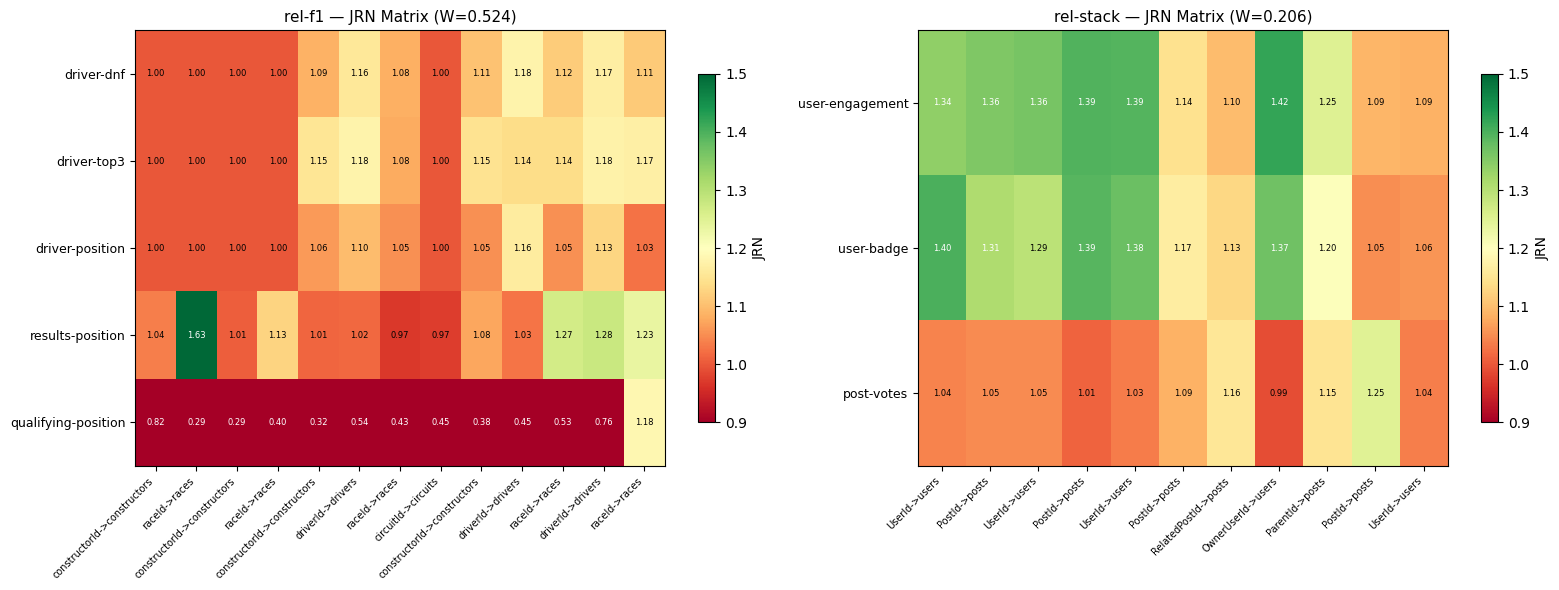

Saved jrn_heatmaps.png


In [12]:
# --- Summary Table ---
print("=" * 70)
print("CROSS-DATASET SUMMARY")
print("=" * 70)
summary_rows = []
for ds_name, ds_data in all_dataset_results.items():
    row = {
        "Dataset": ds_name,
        "Tasks": ds_data["concordance_analysis"]["num_tasks"],
        "Joins": ds_data["concordance_analysis"]["num_joins"],
        "Kendall's W": f"{ds_data['concordance_analysis']['kendalls_W']:.4f}",
        "Transfer rho": f"{ds_data['transfer_analysis']['mean_transfer_rho']:.4f}",
        "Same-entity rho": f"{ds_data['task_type_analysis']['same_entity_mean_rho']:.4f}" if ds_data['task_type_analysis']['same_entity_mean_rho'] is not None else "N/A",
        "Cross-entity rho": f"{ds_data['task_type_analysis']['cross_entity_mean_rho']:.4f}" if ds_data['task_type_analysis']['cross_entity_mean_rho'] is not None else "N/A",
        "Gap %": f"{ds_data['practical_impact']['mean_gap_pct']:.2f}",
        "Recommendation": ds_data["cost_adjusted"]["recommendation"],
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# --- JRN Heatmaps ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (ds_name, ds_data) in enumerate(all_dataset_results.items()):
    ax = axes[idx]
    jrn_matrix = ds_data["jrn_matrix"]
    tasks = list(jrn_matrix.keys())
    all_join_sets = [set(jrn_matrix[t].keys()) for t in tasks]
    all_joins = sorted(set.union(*all_join_sets))

    # Build matrix
    matrix = np.ones((len(tasks), len(all_joins)))
    for i, t in enumerate(tasks):
        for j, jid in enumerate(all_joins):
            matrix[i, j] = jrn_matrix[t].get(jid, {}).get("jrn_mean", 1.0)

    # Short join labels
    short_joins = [j.split("->")[0].split(".")[-1] + "->" + j.split("->")[1] if "->" in j else j for j in all_joins]

    im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto", vmin=0.9, vmax=1.5)
    ax.set_xticks(range(len(short_joins)))
    ax.set_xticklabels(short_joins, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(tasks)))
    ax.set_yticklabels(tasks, fontsize=9)
    ax.set_title(f"{ds_name} — JRN Matrix (W={ds_data['concordance_analysis']['kendalls_W']:.3f})", fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8, label="JRN")

    # Annotate values
    for i in range(len(tasks)):
        for j in range(len(all_joins)):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if matrix[i, j] > 1.3 or matrix[i, j] < 0.95 else "black")

plt.tight_layout()
plt.savefig("jrn_heatmaps.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved jrn_heatmaps.png")

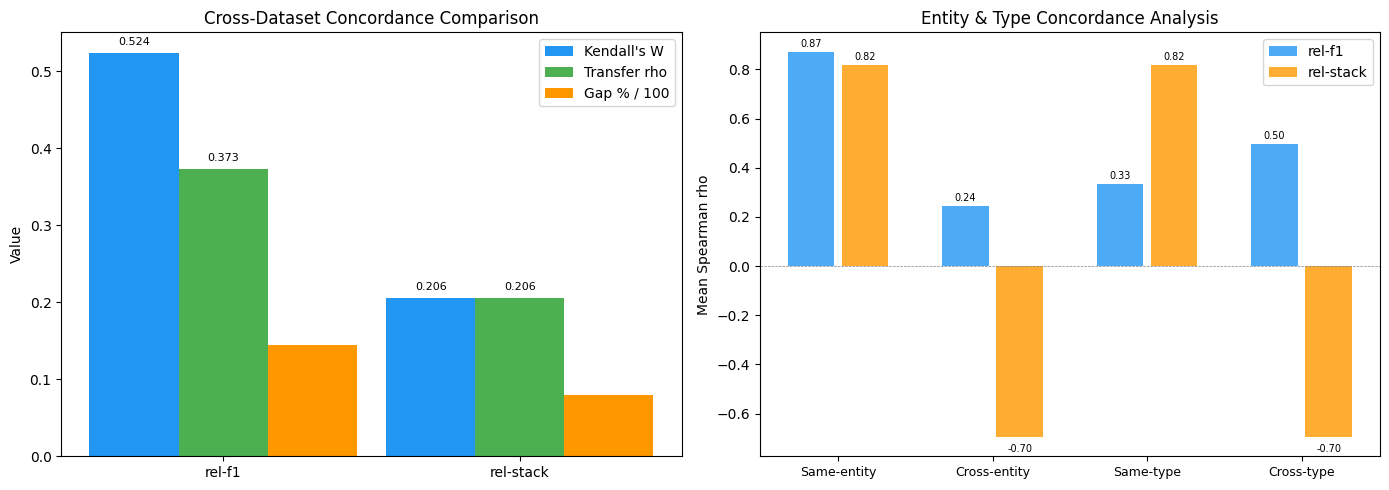

Saved concordance_comparison.png

Done! Both datasets recommend per-task JRN due to gaps >5%.


In [13]:
# --- Concordance Comparison Bar Chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Kendall's W and Transfer rho comparison
ds_names = list(all_dataset_results.keys())
W_vals = [all_dataset_results[d]["concordance_analysis"]["kendalls_W"] for d in ds_names]
rho_vals = [all_dataset_results[d]["transfer_analysis"]["mean_transfer_rho"] for d in ds_names]
gap_vals = [all_dataset_results[d]["practical_impact"]["mean_gap_pct"] for d in ds_names]

x = np.arange(len(ds_names))
width = 0.3
bars1 = axes[0].bar(x - width, W_vals, width, label="Kendall's W", color="#2196F3")
bars2 = axes[0].bar(x, rho_vals, width, label="Transfer rho", color="#4CAF50")
bars3 = axes[0].bar(x + width, [g / 100 for g in gap_vals], width, label="Gap % / 100", color="#FF9800")
axes[0].set_xticks(x)
axes[0].set_xticklabels(ds_names)
axes[0].set_ylabel("Value")
axes[0].set_title("Cross-Dataset Concordance Comparison")
axes[0].legend()
axes[0].axhline(y=0, color="gray", linestyle="--", linewidth=0.5)

for bar, val in zip(bars1, W_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha="center", fontsize=8)
for bar, val in zip(bars2, rho_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha="center", fontsize=8)

# Plot 2: Same-entity vs Cross-entity rho
categories = ["Same-entity", "Cross-entity", "Same-type", "Cross-type"]
for idx, ds_name in enumerate(ds_names):
    tt = all_dataset_results[ds_name]["task_type_analysis"]
    vals = [
        tt["same_entity_mean_rho"] or 0,
        tt["cross_entity_mean_rho"] or 0,
        tt["same_type_mean_rho"] or 0,
        tt["cross_type_mean_rho"] or 0,
    ]
    x_pos = np.arange(len(categories))
    offset = (idx - 0.5) * 0.35
    bars = axes[1].bar(x_pos + offset, vals, 0.3, label=ds_name,
                       color=["#2196F3", "#FF9800"][idx], alpha=0.8)
    for bar, val in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02 if val >= 0 else bar.get_height() - 0.06,
                     f"{val:.2f}", ha="center", fontsize=7)

axes[1].set_xticks(np.arange(len(categories)))
axes[1].set_xticklabels(categories, fontsize=9)
axes[1].set_ylabel("Mean Spearman rho")
axes[1].set_title("Entity & Type Concordance Analysis")
axes[1].legend()
axes[1].axhline(y=0, color="gray", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.savefig("concordance_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved concordance_comparison.png")
print("\nDone! Both datasets recommend per-task JRN due to gaps >5%.")